<a href="https://colab.research.google.com/github/satin-vasita/DSPY-Practicals-Colab-Notebooks/blob/main/Miniproject3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve)
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE


In [2]:
"""
PROBLEM STATEMENT:
Given passenger booking attributes (lead time, add-ons, trip type, sales channel etc.),
predict whether a customer will COMPLETE their booking (booking_complete = 1).

Type     : Binary Classification
Target   : booking_complete (0 = Not Completed, 1 = Completed)
Use Case : Airlines can use this to identify drop-off risk and send nudges/offers.
"""

'\nPROBLEM STATEMENT:\nGiven passenger booking attributes (lead time, add-ons, trip type, sales channel etc.),\npredict whether a customer will COMPLETE their booking (booking_complete = 1).\n\nType     : Binary Classification\nTarget   : booking_complete (0 = Not Completed, 1 = Completed)\nUse Case : Airlines can use this to identify drop-off risk and send nudges/offers.\n'

In [3]:
# CELL 3 — Load Data & Define X, y
df = pd.read_csv('cleaned_airline_data.csv')
X = df.drop(columns=['booking_complete'])
y = df['booking_complete']
print("Class distribution:\n", y.value_counts())

Class distribution:
 booking_complete
0    41890
1     7391
Name: count, dtype: int64


In [4]:
# CELL 4 — Train-Test Split + SMOTE (Handle Class Imbalance)
# Dataset is ~85:15 imbalanced. SMOTE applied only on train set to avoid leakage.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                      random_state=42, stratify=y)
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)
print("After SMOTE:", pd.Series(y_train).value_counts())

After SMOTE: booking_complete
0    33511
1    33511
Name: count, dtype: int64


In [5]:
# CELL 5 — Feature Scaling
# Fit scaler on train only to prevent data leakage into test set.
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [6]:
# CELL 6 — Train Models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost':             XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    results[name] = {
        'model': model, 'y_pred': y_pred, 'y_prob': y_prob,
        'accuracy': accuracy_score(y_test, y_pred),
        'auc': roc_auc_score(y_test, y_prob)
    }
    print(f"\n{'='*40}\n{name}")
    print(f"Accuracy: {results[name]['accuracy']:.4f} | AUC: {results[name]['auc']:.4f}")
    print(classification_report(y_test, y_pred))



Logistic Regression
Accuracy: 0.5635 | AUC: 0.5535
              precision    recall  f1-score   support

           0       0.87      0.57      0.69      8379
           1       0.17      0.50      0.26      1478

    accuracy                           0.56      9857
   macro avg       0.52      0.54      0.47      9857
weighted avg       0.76      0.56      0.63      9857


Random Forest
Accuracy: 0.8049 | AUC: 0.6216
              precision    recall  f1-score   support

           0       0.86      0.92      0.89      8379
           1       0.26      0.16      0.20      1478

    accuracy                           0.80      9857
   macro avg       0.56      0.54      0.54      9857
weighted avg       0.77      0.80      0.79      9857


XGBoost
Accuracy: 0.8228 | AUC: 0.6498
              precision    recall  f1-score   support

           0       0.86      0.95      0.90      8379
           1       0.28      0.12      0.17      1478

    accuracy                           0.82 

In [7]:
# CELL 7 — Cross Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for name, info in results.items():
    scores = cross_val_score(info['model'], X_train, y_train, cv=cv, scoring='roc_auc')
    print(f"{name}: Mean AUC = {scores.mean():.4f} ± {scores.std():.4f}")

Logistic Regression: Mean AUC = 0.6837 ± 0.0018
Random Forest: Mean AUC = 0.9402 ± 0.0018
XGBoost: Mean AUC = 0.9205 ± 0.0036


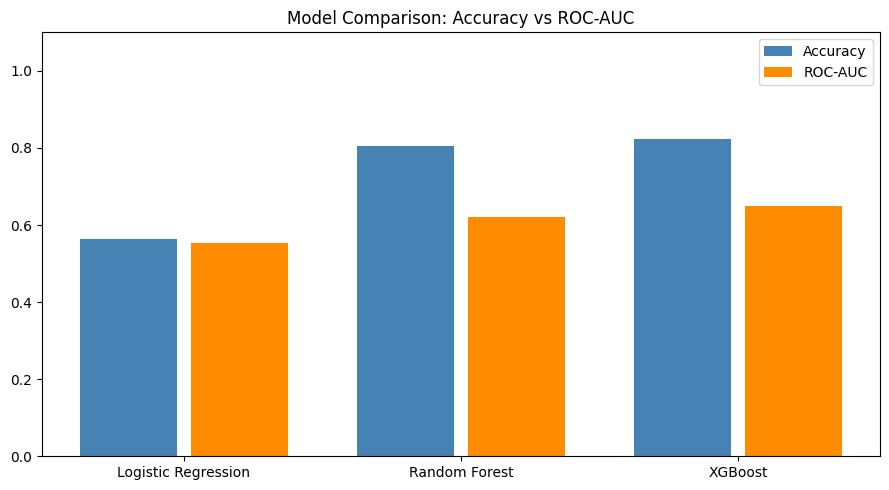

In [8]:
names = list(results.keys())
accs = [results[m]['accuracy'] for m in names]
aucs = [results[m]['auc'] for m in names]
x = np.arange(len(names))

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - 0.2, accs, 0.35, label='Accuracy', color='steelblue')
ax.bar(x + 0.2, aucs, 0.35, label='ROC-AUC', color='darkorange')
ax.set_xticks(x); ax.set_xticklabels(names)
ax.set_ylim(0, 1.1); ax.legend()
ax.set_title('Model Comparison: Accuracy vs ROC-AUC')
plt.tight_layout(); plt.show()

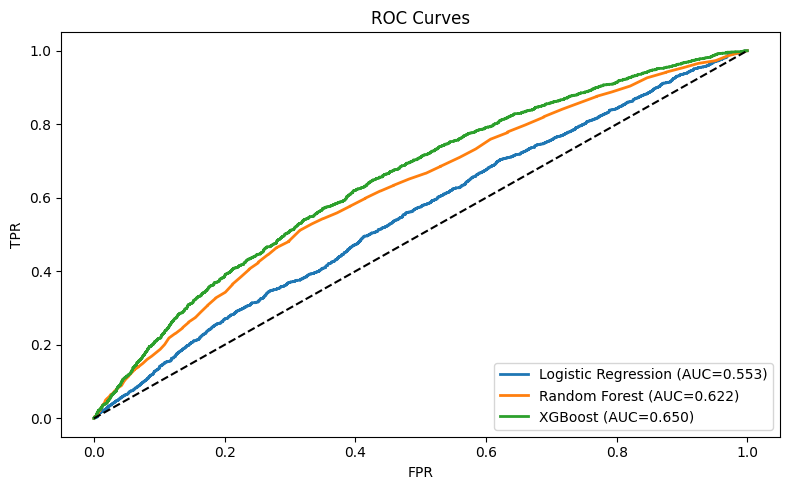

In [9]:
# CELL 9 — ROC Curves
plt.figure(figsize=(8, 5))
for name, info in results.items():
    fpr, tpr, _ = roc_curve(y_test, info['y_prob'])
    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC={info['auc']:.3f})")
plt.plot([0,1],[0,1],'k--')
plt.xlabel('FPR'); plt.ylabel('TPR')
plt.title('ROC Curves'); plt.legend(loc='lower right')
plt.tight_layout(); plt.show()


Best Model: XGBoost


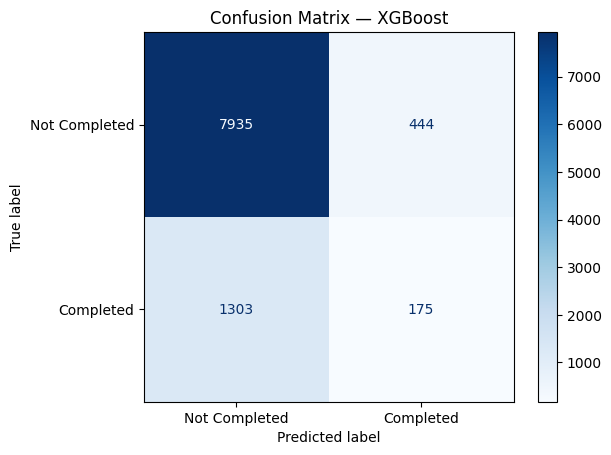

In [10]:
# CELL 10 — Confusion Matrix (Best Model)
best = max(results, key=lambda x: results[x]['auc'])
print(f"Best Model: {best}")
cm = confusion_matrix(y_test, results[best]['y_pred'])
ConfusionMatrixDisplay(cm, display_labels=['Not Completed','Completed']).plot(cmap='Blues')
plt.title(f'Confusion Matrix — {best}'); plt.show()


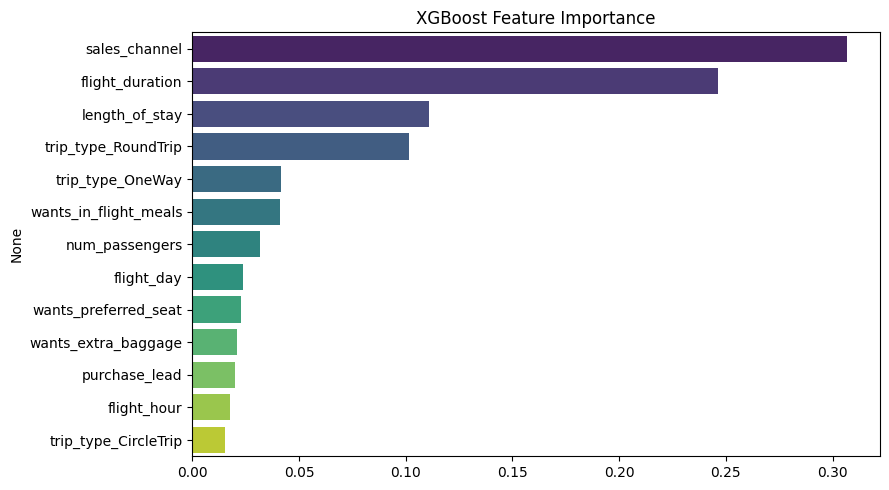

sales_channel          0.306865
flight_duration        0.246410
length_of_stay         0.110701
trip_type_RoundTrip    0.101589
trip_type_OneWay       0.041358
dtype: float32


In [11]:
# CELL 11 — Feature Importance (XGBoost)
feat_imp = pd.Series(results['XGBoost']['model'].feature_importances_,
                     index=df.drop(columns=['booking_complete']).columns).sort_values(ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='viridis')
plt.title('XGBoost Feature Importance'); plt.tight_layout(); plt.show()
print(feat_imp.head(5))


In [12]:
# CELL 12 — Summary (Markdown Cell in Jupyter)
"""
ML LIFECYCLE SUMMARY:
1. Problem Definition  → Binary classification: predict booking_complete
2. Data Preparation    → Loaded cleaned data, split X and y
3. Imbalance Handling  → SMOTE on training set only
4. Feature Scaling     → StandardScaler (fit on train, transform test)
5. Model Training      → Logistic Regression, Random Forest, XGBoost
6. Evaluation          → Accuracy, ROC-AUC, Cross-Validation, Confusion Matrix
7. Model Selection     → XGBoost gave highest ROC-AUC
8. Interpretability    → Add-ons (baggage, seat, meals) and purchase_lead are top features

CONCLUSION: XGBoost is the recommended model. Airlines can deploy it to flag
customers likely to abandon their booking and intervene with targeted offers.
"""
summary = pd.DataFrame({'Model': names, 'Accuracy': accs, 'ROC-AUC': aucs})
print(summary.sort_values('ROC-AUC', ascending=False).to_string(index=False))

              Model  Accuracy  ROC-AUC
            XGBoost  0.822766 0.649752
      Random Forest  0.804910 0.621597
Logistic Regression  0.563457 0.553455
